# Análise da Carga

In [43]:
CARGA = "data/videos/minecraft_trailer.mp4"

In [3]:
import cv2
import matplotlib.pyplot as plt

In [52]:
def caracterizar_video(caminho_video):
    """
    Identifica metadados do vídeo de entrada
    """
    cap = cv2.VideoCapture(caminho_video)

    if not cap.isOpened():
        print(f"Erro: Não foi possível abrir o vídeo {caminho_video}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Codec (FOURCC)
    codec_int = int(cap.get(cv2.CAP_PROP_FOURCC))
    codec_str = "".join([chr((codec_int >> 8 * i) & 0xFF) for i in range(4)])

    # Duração
    duracao_segundos = total_frames / fps if fps > 0 else 0

    print("—"*50)
    print("\033[95mCaracterização da Entrada (Baseline)\033[0m")
    print("—"*50)
    print(f"Arquivo: {caminho_video}")
    print(f"Resolução: {largura}x{altura}")
    print(f"FPS: {fps:.2f}")
    print(f"Total de Frames: {total_frames}")
    print(f"Duração: {duracao_segundos:.2f} segundos")
    print(f"Codec (FOURCC): {codec_str}")

    cap.release()

In [53]:
def visualizar_frames_ground_truth(caminho_video, indices_frames):
    """
    Extrai e exibe frames específicos de um vídeo num Jupyter Notebook.
    """
    cap = cv2.VideoCapture(caminho_video)

    indices_frames = indices_frames if isinstance(indices_frames, list) else [indices_frames]
    if not cap.isOpened():
        print("Erro ao abrir o vídeo.")
        return

    # Define o tamanho da figura
    num_frames = len(indices_frames)
    fig, axes = plt.subplots(1, num_frames, figsize=(4 * num_frames, 4))

    if num_frames == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        sucesso, frame = cap.read()

        if sucesso:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            ax.imshow(frame_rgb)
            ax.set_title(f"Corte no Frame: {idx}", fontsize=12)
            ax.axis('off')
        else:
            ax.set_title(f"Falha ao ler frame {idx}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Libera o arquivo da memória
    cap.release()

In [54]:
caracterizar_video(CARGA)

——————————————————————————————————————————————————
Caracterização da Entrada (Baseline)
——————————————————————————————————————————————————
Arquivo: data/videos/minecraft_trailer.mp4
Resolução: 854x480
FPS: 23.98
Total de Frames: 1439
Duração: 60.02 segundos
Codec (FOURCC): h264


In [21]:
with open("manual/minecraft_trailer.txt", "r") as f:
    indices_frames_minecraft = list(map(int, f.read().strip().split(',')))

In [ ]:
for idx in indices_frames_minecraft:
    visualizar_frames_ground_truth("data/videos/minecraft_trailer.mp4", idx)

# Análise Estatística
**Trilha:** Processamento de Imagens / Visão Computacional\
**Cenário:** Topologia de Grid BIC (Retângulo Central)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

sns.set_theme(style="whitegrid", context="paper")

df = pd.read_csv("baseline.csv")
tempos = df["valor"].values

## 1. Estatística Descritiva e Incerteza (IC)

Para calcular a dispersão dos dados, utiliza-se o desvio padrão amostral. O parâmetro `ddof=1` (Delta Degrees of Freedom) aplica a Correção de Bessel, dividindo a variância por $N-1$ em vez de $N$, o que gera uma estimativa não-viesada da variabilidade populacional.

Como estamos trabalhando com uma amostra do desempenho do sistema, a incerteza é modelada através de um **Intervalo de Confiança (IC)** usando a distribuição *T de Student* bicaudal. O IC define a margem dentro da qual o tempo médio verdadeiro do sistema deve se encontrar.

In [32]:
media = np.mean(tempos)
mediana = np.median(tempos)
minimo = np.min(tempos)
maximo = np.max(tempos)
desvio_padrao = np.std(tempos, ddof=1) # ddof=1 garante variância amostral

# IC
confianca = 0.99
n = len(tempos)
alpha = 1 - confianca

# Valor crítico da distribuição t
t_critico = t.ppf(1 - alpha/2, df=n-1)

# Erro padrão média
erro_padrao = desvio_padrao / np.sqrt(n)

# Limites IC
margem_erro = t_critico * erro_padrao
ic_inferior = media - margem_erro
ic_superior = media + margem_erro

In [56]:
print("—" * 50)
print(f"\033[95mAnálise Estatística do Baseline \033[35m(n={n})\033[0m")
print("—" * 50)
print(f"Mínimo:        {minimo:.3f} ms")
print(f"Máximo:        {maximo:.3f} ms")
print(f"Mediana:       {mediana:.3f} ms")
print(f"Média:         {media:.3f} ms")
print(f"Desvio Padrão: {desvio_padrao:.3f} ms")
print("—" * 50)
print(f"IC 99% da Média: [{ic_inferior:.3f} ms, {ic_superior:.3f} ms]")
print(f"Margem de Erro:  ± {margem_erro:.3f} ms")
print("—" * 50)

——————————————————————————————————————————————————
Análise Estatística do Baseline (n=47)
——————————————————————————————————————————————————
Mínimo:        71.683 ms
Máximo:        78.740 ms
Mediana:       76.168 ms
Média:         75.995 ms
Desvio Padrão: 1.753 ms
——————————————————————————————————————————————————
IC 99% da Média: [75.308 ms, 76.682 ms]
Margem de Erro:  ± 0.687 ms
——————————————————————————————————————————————————


## 2. Visualização de Dados

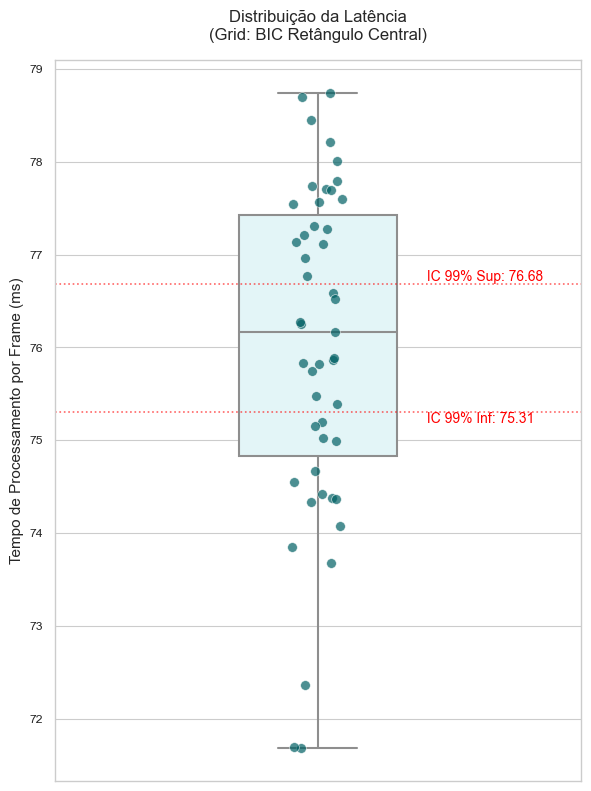

In [40]:
# Criação da figura e eixos
fig, ax = plt.subplots(figsize=(6, 8))

# Boxplot
sns.boxplot(
    y=tempos,
    width=0.3,
    color='#E0F7FA',
    linewidth=1.5,
    showfliers=False,
    ax=ax
)

# Strip Plot
sns.stripplot(
    y=tempos,
    color='#006064',
    alpha=0.7,
    jitter=0.05,
    size=7,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

# Anotação do IC
ax.axhline(ic_superior, color='red', linestyle=':', alpha=0.6)
ax.axhline(ic_inferior, color='red', linestyle=':', alpha=0.6)
ax.text(0.2, ic_superior, f" IC 99% Sup: {ic_superior:.2f}", color='red', va='bottom', fontsize=10)
ax.text(0.2, ic_inferior, f" IC 99% Inf: {ic_inferior:.2f}", color='red', va='top', fontsize=10)

# Formatação Limpa do Gráfico
ax.set_title("Distribuição da Latência\n(Grid: BIC Retângulo Central)", fontsize=12, pad=15)
ax.set_ylabel("Tempo de Processamento por Frame (ms)", fontsize=11)

ax.set_xticks([])

plt.tight_layout()

plt.show()